---
title: "Lecture 6: Classical iterative methods"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture6_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Classical Iterative Methods for Solving Linear Systems

 

## Jacobi's Method

The first method hinges on the observation that if $\mathbf{A}\mathbf{x} = \mathbf{b}$ then $$A_{i1}x_1 + A_{i2}x_2 + \cdots + A_{ii}x_i + \cdots + A_{in} x_n = b_i \text{ for } i = 1, \cdots, n.$$

. . .

This can be arranged as $$x_i = \frac{1}{A_{ii}} \left[ \sum_{j = 1\\j\not= i}^n (-A_{ij}x_j) + b_i \right] \text{ for } i=1, \cdots, n.$$

---

Jacobi's method uses this observation iteratively, forcing the $i$th component of the current approximation to satisfy the $i$th equation, that is $\mathbf{x}^{(k)}$ satisfies $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1\\j\not= i}^n (-A_{ij}x_j^{(k-1)}) + b_i \right] \text{ for } i=1, \cdots, n.$$

. . .

::: {.callout-caution icon=false}
## Exercise: Sketch Jacobi's method
Sketch two iterations of Jacobi's method applied to the system visualized below with the given initial iterate, $\mathbf{x}^{(0)}$.
:::
<details><summary>System:</summary> 

![](figs/system_empty.png){height=200}
</details>

<details><summary>Answer:</summary> 

![](figs/jacobi_steps.png){height=200}
</details>

[You should also think about what happens here if the order of the equations is changed or if the initial iterate is somewhere else.  Spoiler alert: Jacobi's method doesn't always converge!]{.content-hidden when-format='revealjs' when-format='pptx'} 

## Matrix-vector form of Jacobi update

We can collect all of the updates to the coordinates of $\mathbf{x}^{(k)}$ together into a vector update.  

. . .

Note that we can rewrite $\mathbf{A}\mathbf{x} = \mathbf{b}$ as $$\mathbf{D}(\mathbf{A})\mathbf{x} + \mathbf{L}(\mathbf{A})\mathbf{x} + \mathbf{U}(\mathbf{A})\mathbf{x} = \mathbf{b}$$ where $\mathbf{D}(\mathbf{A})$ is the diagonal matrix containing the diagonal elements of $\mathbf{A}$, $\mathbf{L}(\mathbf{A})$ is the strictly lower-triangular matrix containing the strictly lower-triangular elements of $\mathbf{A}$, and $\mathbf{U}(\mathbf{A})$ is the strictly upper-triangular matrix containing the strictly upper-triangular elements of $\mathbf{A}$.

. . .

In this notation, the Jacobi iterates satisfy $$\mathbf{D}(\mathbf{A})\mathbf{x}^{(k)} + [\mathbf{L}(\mathbf{A}) + \mathbf{U}(\mathbf{A})] \mathbf{x}^{(k-1)} = \mathbf{b} $$

. . .

and so, $$\mathbf{x}^{(k)} = -\mathbf{D}(\mathbf{A})^{-1} [\mathbf{L}(\mathbf{A}) + \mathbf{U}(\mathbf{A})] \mathbf{x}^{(k-1)} + \mathbf{D}(\mathbf{A})^{-1} \mathbf{b}.$$

---

In [200]:
"""
    jacobi(A,b,x_0,N)

Run N iterations of Jacobi's method on system Ax=b with initial iterate x_0.
"""
function jacobi(A,b,x_0,N,x_true)
    D = Diagonal(A);
    L = tril(A,-1);
    U = triu(A,1);

    x_old = x_0
    errs = zeros(N+1)
    errs[1] = norm(x_old - x_true)/norm(x_true)
    for i in 1:N
        x_new = D\(-(L+U)*x_old + b);
        errs[i+1] = norm(x_new - x_true)/norm(x_true);
        x_old = x_new;
    end
    return x, errs
end


jacobi

---

Now, we'll run a small experiment to check that our code works!

In [201]:
n = 100
#A = randn(n,n)
A = diagm(ones(n)) + 0.05*randn(n,n)
x_true = ones(n)
b = A*x_true;

In [204]:
N = 100
x, errs = jacobi(A,b,zeros(n),N,x_true);

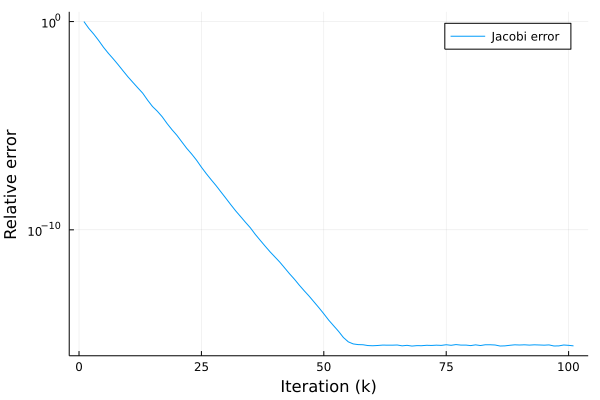

In [209]:
plot(1:N+1,errs,yscale=:log10,label="Jacobi error",xaxis="Iteration (k)", yaxis="Relative error")

## Gauss-Seidel method

We can possibly improve Jacobi's method by taking a second look at the equation $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1\\j\not= i}^n (-A_{ij}x_j^{(k-1)}) + b_i \right] \text{ for } i=1, \cdots, n.$$

. . .

If we think about doing the updates to the entries of $\mathbf{x}^{(k)}$ sequentially, we see that we update $x^{(k)}_1$ before updating $x^{(k)}_2$, but in the update of $x^{(k)}_2$, we use $x^{(k-1)}_1$, despite having the (likely better) estimate for the first entry computed in $x^{(k)}_1$.  

. . .

This motivates using the most up-to-date estimates available in this update: $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1}^{i-1} (-A_{ij}x_j^{(k)}) \sum_{j = i+1}^{n} (-A_{ij}x_j^{(k-1)})+ b_i \right] \text{ for } i=1, \cdots, n.$$

---

::: {.callout-caution icon=false}
## Exercise: Sketch the Gauss-Seidel method
Sketch two iterations of the Gauss-Seidel method applied to the system visualized below with the given initial iterate, $\mathbf{x}^{(0)}$.
:::
<details><summary>System:</summary> 

![](figs/system_empty.png){height=300}
</details>

<details><summary>Answer:</summary> 

![](figs/gs_steps.png){height=300}
</details>

## Matrix-vector form of G-S update

In the same way we did for Jacobi, we can succinctly write the Gauss-Seidel update in matrix-vector form.  

. . .

Noting, now, that the update $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1}^{i-1} (-A_{ij}x_j^{(k)}) \sum_{j = i+1}^{n} (-A_{ij}x_j^{(k-1)})+ b_i \right] \text{ for } i=1, \cdots, n$$ involves the entire lower triangular part of $\mathbf{A}$ interacting with entries of $\mathbf{x}^{(k)}$, 

. . .

we can rewrite this as $$[\mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A})]\mathbf{x}^{(k)} + \mathbf{U}(\mathbf{A}) \mathbf{x}^{(k-1)} = \mathbf{b}.$$

. . .

Thus, the update is $$\mathbf{x}^{(k)} = -[\mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A})]^{-1} \mathbf{U}(\mathbf{A}) \mathbf{x}^{(k-1)} + [\mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A})]^{-1} \mathbf{b}.$$

---
::: {.callout-caution icon=false}
## Exercise: Implement the Gauss-Seidel method
Complete the Gauss-Seidel method code below and run this method on the same experimental system above.
:::

In [210]:
"""
    gaussseidel(A,b,x_0,N)

Run N iterations of the Gauss-Seidel method on system Ax=b with initial iterate x_0.
"""
function gaussseidel(A,b,x_0,N,x_true)
    D = Diagonal(A);
    L = tril(A,-1);
    U = triu(A,1);

    x_old = x_0
    errs = zeros(N+1)
    errs[1] = norm(x_old - x_true)/norm(x_true)
    for i in 1:N
        x_new = ############################################### complete this code!
        errs[i+1] = norm(x_new - x_true)/norm(x_true);
        x_old = x_new;
    end
    return x, errs
end

gaussseidel

## Kaczmarz method

The Jacobi and Gauss-Seidel methods update using individual coordinate direction updates onto the hyperplanes defined by the individual equations.  This is not the only way that the iterates can move towards these hyperplanes!

. . .

Perhaps the most natural updating strategy is to project each iterate onto a hyperplane to produce the subsequent iterate.  This strategy is known as the *Kaczmarz method*.

![](figs/kaczmarz_steps.png){height=300}

. . .

The update for this type of method is given by $\mathbf{x}^{(k)} = \mathbf{x}^{(k-1)} + \frac{b_i - \mathbf{a}_i^\top \mathbf{x}^{(k-1)}}{\|\mathbf{a}_i\|^2} \mathbf{a}_i$ where $\mathbf{a}_i$ is the $i$th row of $\mathbf{A}$ and $i$ is chosen from $1, \cdots, n$.

##

::: {.callout-caution icon=false}
## Exercise: Decreasing error
If $\mathbf{x}^*$ satisfies $\mathbf{A}\mathbf{x}^* = \mathbf{b}$, then $$\|\mathbf{x}^{(k)} - \mathbf{x}^*\|_2 \le \|\mathbf{x}^{(k-1)} - \mathbf{x}^*\|_2.$$  Show that this is true!
:::

<details><summary>Answer:</summary> 
Note that $\mathbf{x}^*$ lies in the intersection of all hyperplane solution sets, and the three vector $\mathbf{x}^{(k)} - \mathbf{x}^*$, $\mathbf{x}^{(k-1)} - \mathbf{x}^*$, and $\mathbf{x}^{(k)} - \mathbf{x}^{(k-1)}$ form the edges of a right triangle.  By the Pythagorean theorem, we have $$\|\mathbf{x}^{(k-1)} - \mathbf{x}^*\|^2 = \|\mathbf{x}^{(k)} - \mathbf{x}^*\|^2 + \|\mathbf{x}^{(k)} - \mathbf{x}^{(k-1)}\|^2.$$  The result follows since $\|\mathbf{x}^{(k)} - \mathbf{x}^{(k-1)}\|^2 \ge 0$.  
</details>